<a href="https://colab.research.google.com/github/Cmichs90/Cmichs.github.io/blob/main/Group_Work_Project_1_M5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize, differential_evolution
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings("ignore")

# Step 1
**Team Member A**

In [ ]:
S0 = 232.90
r = 0.015
trading_days = 250

file_path = "/content/SMOptionsData.xlsx"

df_raw = pd.read_excel(file_path)
df_raw.columns = ["DaysToMaturity", "Strike", "Price", "Type"]

df = df_raw.copy()
df["Type"] = df["Type"].astype(str).str.strip().str.upper()
df["DaysToMaturity"] = pd.to_numeric(df["DaysToMaturity"], errors="coerce")
df["Strike"] = pd.to_numeric(df["Strike"], errors="coerce")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df = df.dropna(subset=["DaysToMaturity", "Strike", "Price", "Type"]).reset_index(drop=True)
df["T"] = df["DaysToMaturity"] / trading_days

print(df)

    DaysToMaturity  Strike      Price Type     T
0               15   227.5  10.520000    C  0.06
1               15   230.0  10.050000    C  0.06
2               15   232.5   7.750000    C  0.06
3               15   235.0   6.010000    C  0.06
4               15   237.5   4.750000    C  0.06
5               60   227.5  16.780000    C  0.24
6               60   230.0  17.650000    C  0.24
7               60   232.5  16.860000    C  0.24
8               60   235.0  16.050000    C  0.24
9               60   237.5  15.100000    C  0.24
10             120   227.5  27.920000    C  0.48
11             120   230.0  24.120000    C  0.48
12             120   232.5  22.970000    C  0.48
13             120   235.0  21.750000    C  0.48
14             120   237.5  18.060000    C  0.48
15              15   227.5   4.320000    P  0.06
16              15   230.0   5.200000    P  0.06
17              15   232.5   6.450000    P  0.06
18              15   235.0   7.560000    P  0.06
19              15  

In [ ]:
df_15 = df[df["DaysToMaturity"] == 15].copy().reset_index(drop=True)
calls_15 = df_15[df_15["Type"] == "C"].copy().sort_values("Strike").reset_index(drop=True)
puts_15  = df_15[df_15["Type"] == "P"].copy().sort_values("Strike").reset_index(drop=True)

print("15-day calls")
print(calls_15)
print("\n15-day puts")
print(puts_15)

15-day calls
   DaysToMaturity  Strike  Price Type     T
0              15   227.5  10.52    C  0.06
1              15   230.0  10.05    C  0.06
2              15   232.5   7.75    C  0.06
3              15   235.0   6.01    C  0.06
4              15   237.5   4.75    C  0.06

15-day puts
   DaysToMaturity  Strike  Price Type     T
0              15   227.5   4.32    P  0.06
1              15   230.0   5.20    P  0.06
2              15   232.5   6.45    P  0.06
3              15   235.0   7.56    P  0.06
4              15   237.5   8.78    P  0.06


In [ ]:
def heston_cf(u, T, r, kappa, theta, sigma, rho, v0, S0):
    i = 1j
    x = np.log(S0)

    d = np.sqrt((rho * sigma * i * u - kappa)**2 + sigma**2 * (i * u + u**2))
    g = (kappa - rho * sigma * i * u - d) / (kappa - rho * sigma * i * u + d)

    exp_dT = np.exp(-d * T)

    C = r * i * u * T + (kappa * theta / sigma**2) * (
        (kappa - rho * sigma * i * u - d) * T
        - 2 * np.log((1 - g * exp_dT) / (1 - g))
    )
    D = ((kappa - rho * sigma * i * u - d) / sigma**2) * ((1 - exp_dT) / (1 - g * exp_dT))

    return np.exp(C + D * v0 + i * u * x)

In [ ]:
def heston_call_lewis(S0, K, T, r, kappa, theta, sigma, rho, v0):
    i = 1j
    log_moneyness = np.log(S0 / K)

    def integrand(u):
        u_complex = u - 0.5j
        cf_val = heston_cf(u_complex, T, r, kappa, theta, sigma, rho, v0, S0)
        numerator = np.exp(i * u * log_moneyness) * cf_val
        denominator = u**2 + 0.25
        return np.real(numerator / denominator)

    integral_value = quad(integrand, 0, 100, limit=500)[0]
    call_price = S0 - np.exp(-r * T) * np.sqrt(S0 * K) / np.pi * integral_value
    return max(call_price, 0.0)

In [ ]:
def put_from_call_parity(call_price, S0, K, T, r):
    return call_price - S0 + K * np.exp(-r * T)

In [ ]:
def heston_mse_objective(params, calls_df, puts_df, S0, r):
    kappa, theta, sigma, rho, v0 = params

    if kappa <= 0 or theta <= 0 or sigma <= 0 or v0 <= 0 or rho <= -0.999 or rho >= 0.999:
        return 1e10

    # Feller penalty (soft)
    penalty = 0.0
    if 2 * kappa * theta <= sigma**2:
        penalty += 1e4 * (sigma**2 - 2 * kappa * theta + 1e-8)

    sq_errors = []

    for _, row in calls_df.iterrows():
        K, T, market_price = row["Strike"], row["T"], row["Price"]
        model_price = heston_call_lewis(S0, K, T, r, kappa, theta, sigma, rho, v0)
        sq_errors.append((model_price - market_price)**2)

    for _, row in puts_df.iterrows():
        K, T, market_price = row["Strike"], row["T"], row["Price"]
        model_call = heston_call_lewis(S0, K, T, r, kappa, theta, sigma, rho, v0)
        model_put = put_from_call_parity(model_call, S0, K, T, r)
        sq_errors.append((model_put - market_price)**2)

    return np.mean(sq_errors) + penalty

In [ ]:
bounds_heston = [
    (0.01, 15.0),   # kappa
    (0.0001, 1.0),  # theta
    (0.01, 5.0),    # sigma
    (-0.999, 0.999),# rho
    (0.0001, 1.0)   # v0
]

result_global = differential_evolution(
    heston_mse_objective,
    bounds=bounds_heston,
    args=(calls_15, puts_15, S0, r),
    seed=42,
    maxiter=30,
    popsize=15,
    polish=False
)

result_local = minimize(
    heston_mse_objective,
    x0=result_global.x,
    args=(calls_15, puts_15, S0, r),
    method="L-BFGS-B",
    bounds=bounds_heston
)

heston_params = result_local.x
heston_mse = result_local.fun

param_names = ["kappa", "theta", "sigma", "rho", "v0"]
for name, value in zip(param_names, heston_params):
    print(f"{name}: {value:.6f}")
print(f"MSE: {heston_mse:.8f}")

kappa: 14.037965
theta: 0.619830
sigma: 4.151391
rho: 0.999000
v0: 0.192735
MSE: 32.07824604


In [ ]:
kappa, theta, sigma, rho, v0 = heston_params

def price_heston_slice(df_slice, option_type):
    out = df_slice.copy()
    model_prices = []

    for _, row in out.iterrows():
        K, T = row["Strike"], row["T"]
        call_price = heston_call_lewis(S0, K, T, r, kappa, theta, sigma, rho, v0)
        if option_type == "C":
            model_prices.append(call_price)
        else:
            put_price = put_from_call_parity(call_price, S0, K, T, r)
            model_prices.append(put_price)

    out["ModelPrice"] = model_prices
    out["Residual"] = out["ModelPrice"] - out["Price"]
    return out

fit_calls_15 = price_heston_slice(calls_15, "C")
fit_puts_15  = price_heston_slice(puts_15, "P")

print(fit_calls_15)
print(fit_puts_15)

   DaysToMaturity  Strike  Price Type     T  ModelPrice  Residual
0              15   227.5  10.52    C  0.06    5.604864 -4.915136
1              15   230.0  10.05    C  0.06    3.107605 -6.942395
2              15   232.5   7.75    C  0.06    0.609601 -7.140399
3              15   235.0   6.01    C  0.06    0.000000 -6.010000
4              15   237.5   4.75    C  0.06    0.000000 -4.750000
   DaysToMaturity  Strike  Price Type     T  ModelPrice  Residual
0              15   227.5   4.32    P  0.06    0.000206 -4.319794
1              15   230.0   5.20    P  0.06    0.000698 -5.199302
2              15   232.5   6.45    P  0.06    0.000445 -6.449555
3              15   235.0   7.56    P  0.06    1.888595 -5.671405
4              15   237.5   8.78    P  0.06    4.386346 -4.393654


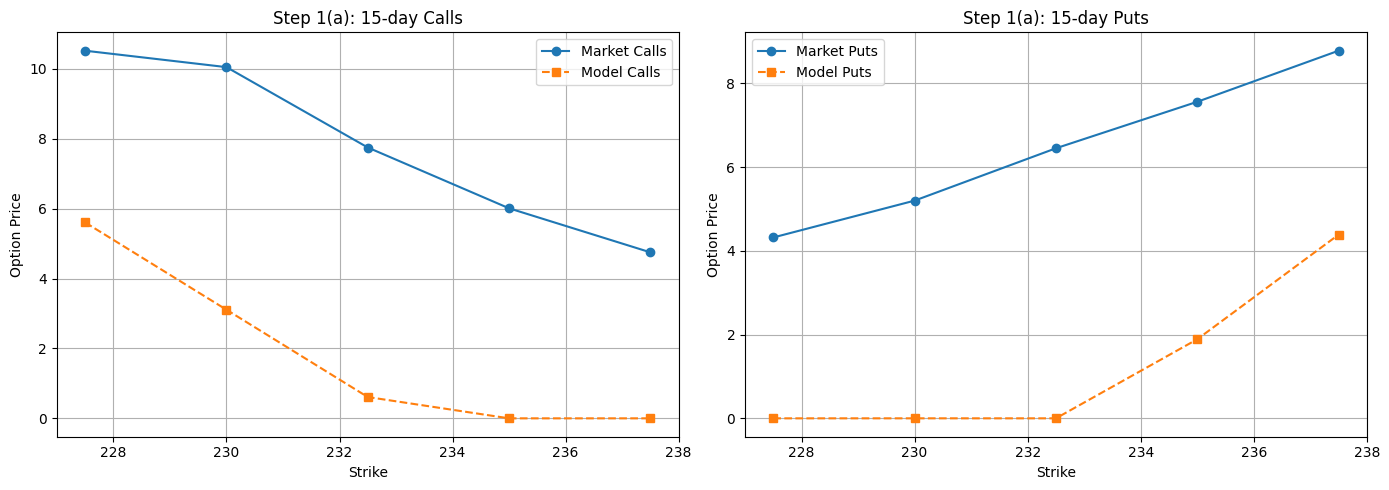

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fit_calls_15["Strike"], fit_calls_15["Price"], "o-", label="Market Calls")
axes[0].plot(fit_calls_15["Strike"], fit_calls_15["ModelPrice"], "s--", label="Model Calls")
axes[0].set_title("Step 1(a): 15-day Calls")
axes[0].set_xlabel("Strike")
axes[0].set_ylabel("Option Price")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(fit_puts_15["Strike"], fit_puts_15["Price"], "o-", label="Market Puts")
axes[1].plot(fit_puts_15["Strike"], fit_puts_15["ModelPrice"], "s--", label="Model Puts")
axes[1].set_title("Step 1(a): 15-day Puts")
axes[1].set_xlabel("Strike")
axes[1].set_ylabel("Option Price")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

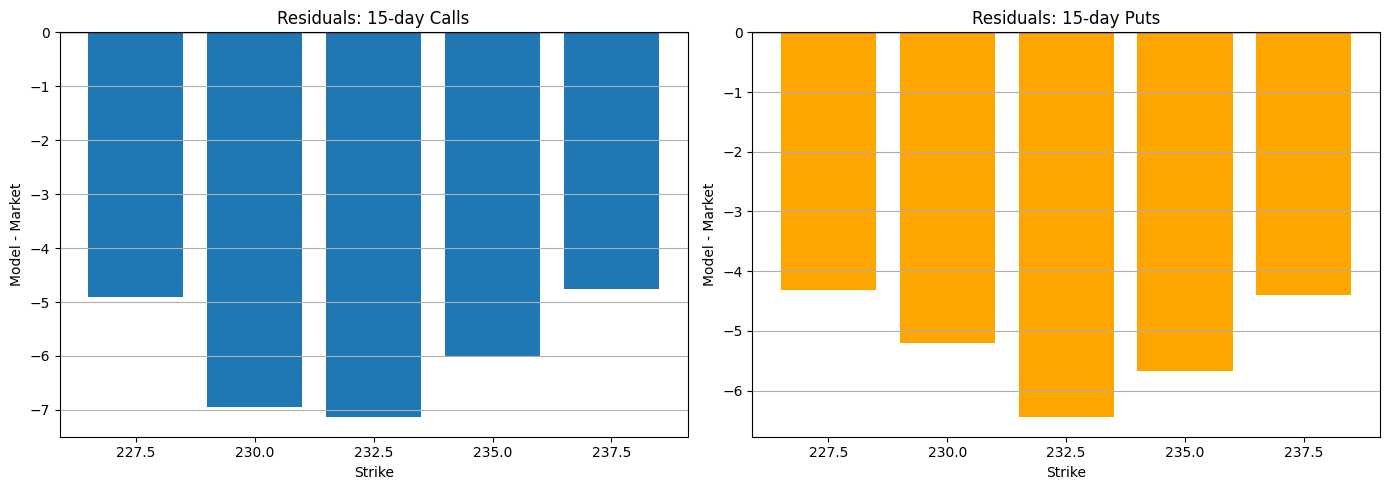

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(fit_calls_15["Strike"].astype(str), fit_calls_15["Residual"])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Residuals: 15-day Calls")
axes[0].set_xlabel("Strike")
axes[0].set_ylabel("Model - Market")
axes[0].grid(True, axis="y")

axes[1].bar(fit_puts_15["Strike"].astype(str), fit_puts_15["Residual"], color="orange")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Residuals: 15-day Puts")
axes[1].set_xlabel("Strike")
axes[1].set_ylabel("Model - Market")
axes[1].grid(True, axis="y")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import differential_evolution, minimize
import warnings
warnings.filterwarnings("ignore")

S0 = 232.90
r = 0.015
TRADING_DAYS = 250
FILE_PATH = "/content/SMOptionsData.xlsx"

In [ ]:
df = pd.read_excel(FILE_PATH)
df.columns = ["Days", "Strike", "Price", "Type"]

df["Days"] = pd.to_numeric(df["Days"], errors="coerce")
df["Strike"] = pd.to_numeric(df["Strike"], errors="coerce")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Type"] = df["Type"].astype(str).str.strip().str.upper()
df = df.dropna().reset_index(drop=True)
df["T"] = df["Days"] / TRADING_DAYS

df15 = df[df["Days"] == 15].copy()
df60 = df[df["Days"] == 60].copy()

calls15 = df15[df15["Type"] == "C"].sort_values("Strike").reset_index(drop=True)
puts15  = df15[df15["Type"] == "P"].sort_values("Strike").reset_index(drop=True)

calls60 = df60[df60["Type"] == "C"].sort_values("Strike").reset_index(drop=True)
puts60  = df60[df60["Type"] == "P"].sort_values("Strike").reset_index(drop=True)

print("15-day options")
display(df15)
print("60-day options")
display(df60)

15-day options


,Days,Strike,Price,Type,T
0,15,227.5,10.52,C,0.06
1,15,230.0,10.05,C,0.06
2,15,232.5,7.75,C,0.06
3,15,235.0,6.01,C,0.06
4,15,237.5,4.75,C,0.06
15,15,227.5,4.32,P,0.06
16,15,230.0,5.20,P,0.06
17,15,232.5,6.45,P,0.06
18,15,235.0,7.56,P,0.06
19,15,237.5,8.78,P,0.06


60-day options


,Days,Strike,Price,Type,T
5,60,227.5,16.78,C,0.24
6,60,230.0,17.65,C,0.24
7,60,232.5,16.86,C,0.24
8,60,235.0,16.05,C,0.24
9,60,237.5,15.10,C,0.24
20,60,227.5,11.03,P,0.24
21,60,230.0,12.15,P,0.24
22,60,232.5,13.37,P,0.24
23,60,235.0,14.75,P,0.24
24,60,237.5,15.62,P,0.24


In [ ]:
def put_from_call_parity(call_price, S0, K, T, r):
    return call_price - S0 + K * np.exp(-r * T)

def plot_fit(call_fit, put_fit, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(call_fit["Strike"], call_fit["Price"], "o-", label="Market Calls")
    axes[0].plot(call_fit["Strike"], call_fit["ModelPrice"], "s--", label="Model Calls")
    axes[0].set_title(f"{title_prefix} Calls")
    axes[0].set_xlabel("Strike")
    axes[0].set_ylabel("Price")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(put_fit["Strike"], put_fit["Price"], "o-", label="Market Puts")
    axes[1].plot(put_fit["Strike"], put_fit["ModelPrice"], "s--", label="Model Puts")
    axes[1].set_title(f"{title_prefix} Puts")
    axes[1].set_xlabel("Strike")
    axes[1].set_ylabel("Price")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def plot_residuals(call_fit, put_fit, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(call_fit["Strike"].astype(str), call_fit["Residual"])
    axes[0].axhline(0, color="black", lw=1)
    axes[0].set_title(f"{title_prefix} Call Residuals")
    axes[0].set_xlabel("Strike")
    axes[0].set_ylabel("Model - Market")
    axes[0].grid(True, axis="y")

    axes[1].bar(put_fit["Strike"].astype(str), put_fit["Residual"], color="orange")
    axes[1].axhline(0, color="black", lw=1)
    axes[1].set_title(f"{title_prefix} Put Residuals")
    axes[1].set_xlabel("Strike")
    axes[1].set_ylabel("Model - Market")
    axes[1].grid(True, axis="y")

    plt.tight_layout()
    plt.show()

In [ ]:
def heston_cf(u, T, r, kappa, theta, sigma, rho, v0, S0):
    i = 1j
    x = np.log(S0)

    d = np.sqrt((rho * sigma * i * u - kappa)**2 + sigma**2 * (u**2 + i * u))
    g = (kappa - rho * sigma * i * u - d) / (kappa - rho * sigma * i * u + d)
    exp_dt = np.exp(-d * T)

    C = r * i * u * T + (kappa * theta / sigma**2) * (
        (kappa - rho * sigma * i * u - d) * T
        - 2 * np.log((1 - g * exp_dt) / (1 - g))
    )
    D = ((kappa - rho * sigma * i * u - d) / sigma**2) * ((1 - exp_dt) / (1 - g * exp_dt))

    return np.exp(i * u * x + C + D * v0)

In [ ]:
def heston_call_lewis(S0, K, T, r, kappa, theta, sigma, rho, v0):
    i = 1j
    log_m = np.log(S0 / K)

    def integrand(u):
        cf_val = heston_cf(u - 0.5j, T, r, kappa, theta, sigma, rho, v0, S0)
        return np.real(np.exp(i * u * log_m) * cf_val / (u**2 + 0.25))

    integral = quad(integrand, 0, 100, limit=300)[0]
    price = S0 - np.exp(-r * T) * np.sqrt(S0 * K) * integral / np.pi
    return max(price, 0.0)

In [ ]:
def heston_mse(params, calls_df, puts_df):
    kappa, theta, sigma, rho, v0 = params

    if kappa <= 0 or theta <= 0 or sigma <= 0 or v0 <= 0 or not (-0.999 < rho < 0.999):
        return 1e10

    penalty = 0.0
    if 2 * kappa * theta <= sigma**2:
        penalty += 1e4

    errors = []

    for _, row in calls_df.iterrows():
        model = heston_call_lewis(S0, row["Strike"], row["T"], r, kappa, theta, sigma, rho, v0)
        errors.append((model - row["Price"])**2)

    for _, row in puts_df.iterrows():
        call_model = heston_call_lewis(S0, row["Strike"], row["T"], r, kappa, theta, sigma, rho, v0)
        put_model = put_from_call_parity(call_model, S0, row["Strike"], row["T"], r)
        errors.append((put_model - row["Price"])**2)

    return np.mean(errors) + penalty

In [ ]:
bounds_heston = [
    (0.01, 15.0),    # kappa
    (0.0001, 1.0),   # theta
    (0.01, 5.0),     # sigma
    (-0.999, 0.999), # rho
    (0.0001, 1.0)    # v0
]

res_g_heston = differential_evolution(
    heston_mse,
    bounds_heston,
    args=(calls15, puts15),
    seed=42,
    maxiter=25,
    popsize=12,
    polish=False
)

res_heston = minimize(
    heston_mse,
    res_g_heston.x,
    args=(calls15, puts15),
    bounds=bounds_heston,
    method="L-BFGS-B"
)

heston_params = res_heston.x
heston_names = ["kappa", "theta", "sigma", "rho", "v0"]

print("Step 1(a) Heston parameters")
for n, v in zip(heston_names, heston_params):
    print(f"{n}: {v:.6f}")
print(f"MSE: {res_heston.fun:.8f}")

Step 1(a) Heston parameters
kappa: 9.133217
theta: 0.172521
sigma: 1.745472
rho: -0.999000
v0: 0.186723
MSE: 32.07983327


,Days,Strike,Price,Type,T,ModelPrice,Residual
0,15,227.5,10.52,C,0.06,5.604524,-4.915476
1,15,230.0,10.05,C,0.06,3.107225,-6.942775
2,15,232.5,7.75,C,0.06,0.609588,-7.140412
3,15,235.0,6.01,C,0.06,0.000000,-6.010000
4,15,237.5,4.75,C,0.06,0.000000,-4.750000


,Days,Strike,Price,Type,T,ModelPrice,Residual
0,15,227.5,4.32,P,0.06,-0.000134,-4.320134
1,15,230.0,5.20,P,0.06,0.000318,-5.199682
2,15,232.5,6.45,P,0.06,0.000432,-6.449568
3,15,235.0,7.56,P,0.06,1.888595,-5.671405
4,15,237.5,8.78,P,0.06,4.386346,-4.393654


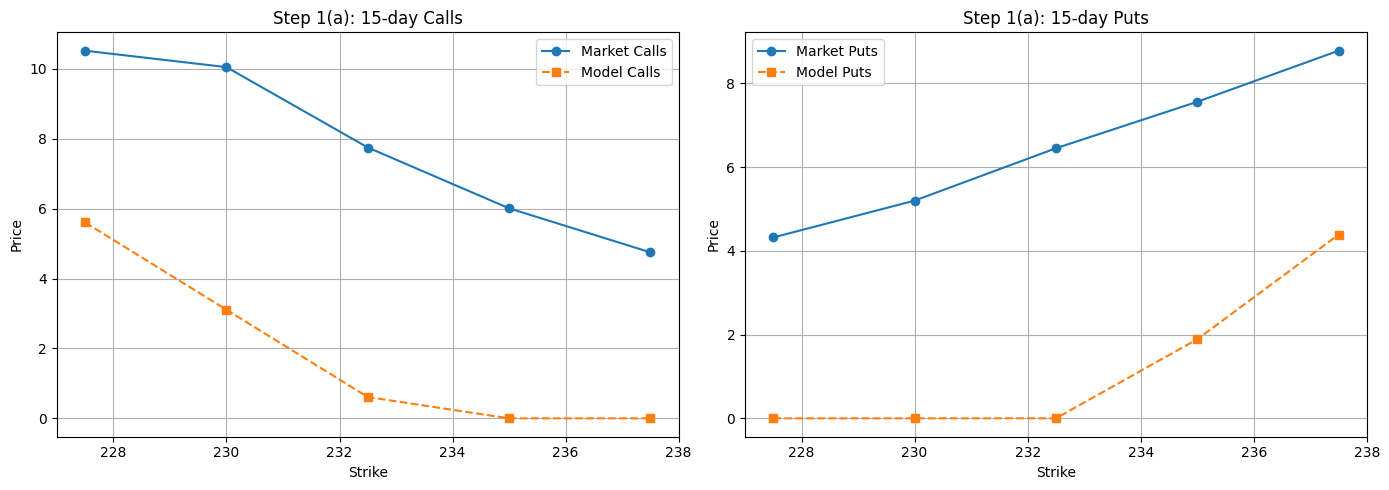

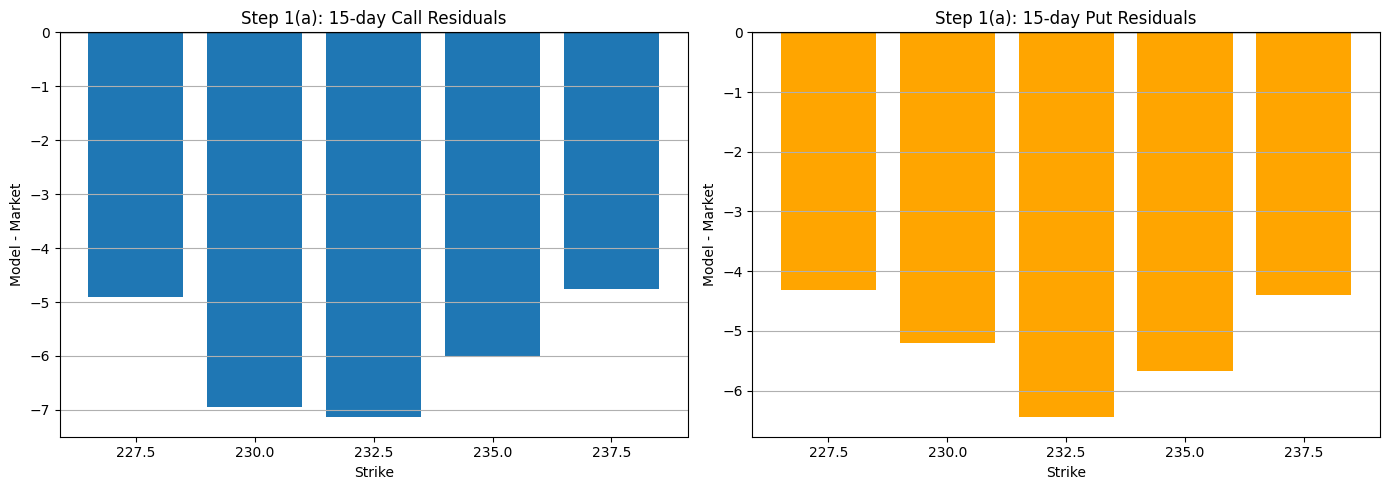

In [ ]:
def fit_heston(df_slice, option_type, params):
    kappa, theta, sigma, rho, v0 = params
    out = df_slice.copy()
    model_prices = []

    for _, row in out.iterrows():
        call_model = heston_call_lewis(S0, row["Strike"], row["T"], r, kappa, theta, sigma, rho, v0)
        if option_type == "C":
            model_prices.append(call_model)
        else:
            model_prices.append(put_from_call_parity(call_model, S0, row["Strike"], row["T"], r))

    out["ModelPrice"] = model_prices
    out["Residual"] = out["ModelPrice"] - out["Price"]
    return out

fit_calls15 = fit_heston(calls15, "C", heston_params)
fit_puts15  = fit_heston(puts15, "P", heston_params)

display(fit_calls15)
display(fit_puts15)

plot_fit(fit_calls15, fit_puts15, "Step 1(a): 15-day")
plot_residuals(fit_calls15, fit_puts15, "Step 1(a): 15-day")

In [ ]:
def bates_cf(u, T, r, kappa, theta, sigma, rho, v0, lamb, muJ, sigmaJ, S0):
    i = 1j
    x = np.log(S0)

    d = np.sqrt((rho * sigma * i * u - kappa)**2 + sigma**2 * (u**2 + i * u))
    g = (kappa - rho * sigma * i * u - d) / (kappa - rho * sigma * i * u + d)
    exp_dt = np.exp(-d * T)

    drift_adj = r - lamb * (np.exp(muJ + 0.5 * sigmaJ**2) - 1)

    C = drift_adj * i * u * T + (kappa * theta / sigma**2) * (
        (kappa - rho * sigma * i * u - d) * T
        - 2 * np.log((1 - g * exp_dt) / (1 - g))
    )
    D = ((kappa - rho * sigma * i * u - d) / sigma**2) * ((1 - exp_dt) / (1 - g * exp_dt))

    jump_part = np.exp(lamb * T * (np.exp(i * u * muJ - 0.5 * sigmaJ**2 * u**2) - 1))

    return np.exp(i * u * x + C + D * v0) * jump_part

In [ ]:
def bates_call_carr_madan(S0, K, T, r, kappa, theta, sigma, rho, v0, lamb, muJ, sigmaJ, alpha=1.5):
    i = 1j
    k = np.log(K)

    def integrand(u):
        phi = bates_cf(u - (alpha + 1) * i, T, r, kappa, theta, sigma, rho, v0, lamb, muJ, sigmaJ, S0)
        denom = alpha**2 + alpha - u**2 + i * (2 * alpha + 1) * u
        return np.real(np.exp(-i * u * k) * np.exp(-r * T) * phi / denom)

    integral = quad(integrand, 0, 100, limit=300)[0]
    price = np.exp(-alpha * k) * integral / np.pi
    return max(price, 0.0)

In [ ]:
def bates_mse(params, calls_df, puts_df):
    kappa, theta, sigma, rho, v0, lamb, muJ, sigmaJ = params

    if kappa <= 0 or theta <= 0 or sigma <= 0 or v0 <= 0 or sigmaJ <= 0 or lamb < 0:
        return 1e10
    if not (-0.999 < rho < 0.999):
        return 1e10

    penalty = 0.0
    if 2 * kappa * theta <= sigma**2:
        penalty += 1e4

    errors = []

    for _, row in calls_df.iterrows():
        model = bates_call_carr_madan(
            S0, row["Strike"], row["T"], r,
            kappa, theta, sigma, rho, v0, lamb, muJ, sigmaJ
        )
        errors.append((model - row["Price"])**2)

    for _, row in puts_df.iterrows():
        call_model = bates_call_carr_madan(
            S0, row["Strike"], row["T"], r,
            kappa, theta, sigma, rho, v0, lamb, muJ, sigmaJ
        )
        put_model = put_from_call_parity(call_model, S0, row["Strike"], row["T"], r)
        errors.append((put_model - row["Price"])**2)

    return np.mean(errors) + penalty

In [ ]:
bounds_bates = [
    (0.01, 15.0),    # kappa
    (0.0001, 1.0),   # theta
    (0.01, 5.0),     # sigma
    (-0.999, 0.999), # rho
    (0.0001, 1.0),   # v0
    (0.0, 5.0),      # lambda
    (-1.0, 1.0),     # muJ
    (0.01, 2.0)      # sigmaJ
]

res_g_bates = differential_evolution(
    bates_mse,
    bounds_bates,
    args=(calls60, puts60),
    seed=42,
    maxiter=25,
    popsize=12,
    polish=False
)

res_bates = minimize(
    bates_mse,
    res_g_bates.x,
    args=(calls60, puts60),
    bounds=bounds_bates,
    method="L-BFGS-B"
)

bates_params = res_bates.x
bates_names = ["kappa", "theta", "sigma", "rho", "v0", "lambda", "muJ", "sigmaJ"]

print("Step 2(b) Bates parameters")
for n, v in zip(bates_names, bates_params):
    print(f"{n}: {v:.6f}")
print(f"MSE: {res_bates.fun:.8f}")

Step 2(b) Bates parameters
kappa: 4.628310
theta: 0.089078
sigma: 4.337056
rho: -0.747005
v0: 0.266807
lambda: 4.977598
muJ: -0.635474
sigmaJ: 1.816224
MSE: 10000000000.00000000


In [ ]:
def fit_bates(df_slice, option_type, params):
    kappa, theta, sigma, rho, v0, lamb, muJ, sigmaJ = params
    out = df_slice.copy()
    model_prices = []

    for _, row in out.iterrows():
        call_model = bates_call_carr_madan(
            S0, row["Strike"], row["T"], r,
            kappa, theta, sigma, rho, v0, lamb, muJ, sigmaJ
        )
        if option_type == "C":
            model_prices.append(call_model)
        else:
            model_prices.append(put_from_call_parity(call_model, S0, row["Strike"], row["T"], r))

    out["ModelPrice"] = model_prices
    out["Residual"] = out["ModelPrice"] - out["Price"]
    return out

fit_calls60 = fit_bates(calls60, "C", bates_params)
fit_puts60  = fit_bates(puts60, "P", bates_params)

display(fit_calls60)
display(fit_puts60)

plot_fit(fit_calls60, fit_puts60, "Step 2(b): 60-day")
plot_residuals(fit_calls60, fit_puts60, "Step 2(b): 60-day")

In [ ]:
summary = pd.DataFrame({
    "Task": ["Step 1(a)"] * 5 + ["Step 2(b)"] * 8,
    "Parameter": heston_names + bates_names,
    "Value": list(heston_params) + list(bates_params)
})

display(summary)